# Generacion de Titulos de Noticias con IA Generativa
## Ciencia de Datos — UTN Facultad Regional La Plata — 2026

---

## 1. Introducción y Motivación

### Qué problema resolvemos?

En el ecosistema de medios digitales, el **titular de una noticia** es la primera —y a veces única— oportunidad de captar la atención del lector. Un buen titular debe ser:

- **Informativo**: reflejar con precisión el contenido del artículo
- **Atractivo**: generar interés y motivar la lectura
- **Conciso**: comunicar la esencia en pocas palabras

Redactores y editores invierten tiempo valioso en este proceso. Este proyecto propone **automatizar la generación de titulares** usando un pipeline de IA Generativa que combina:

1. **Preprocesamiento NLP** (NLTK) para extraer resúmenes y limpiar texto
2. **Embeddings semánticos** (sentence-transformers + GPU) para representación vectorial
3. **Base de datos vectorial** (ChromaDB) para búsqueda semántica y RAG
4. **Modelo generativo** (Gemini 2.0 Flash) con distintas estrategias de prompting
5. **Evaluación cuantitativa** con métricas ROUGE vs. títulos originales

### Por qué es relevante?

- **Volumen**: Los medios digitales publican cientos de artículos por día; la automatización escala
- **Personalización**: Distintas estrategias de prompting generan titulares con diferentes estilos
- **Aprendizaje**: El proyecto integra el ciclo completo de un sistema NLP generativo

### Dataset

Usamos el **BBC News Summary** (Kaggle), con ~2.225 artículos en 5 categorías:
`business`, `entertainment`, `politics`, `sport`, `tech`

### Arquitectura del pipeline

```
Artículo BBC
    │
    ├─► Preprocessor (NLTK) ──► input_summary (3 oraciones)
    │                               │
    │                               ├─► Embedder (GPU) ──► ChromaDB
    │                               │                         │
    │                               │            RAG: artículos similares
    │                               │                         │
    │                               └─► PromptBuilder ◄────────┘
    │                                       │
    │                           [Formal | Impactful | SEO]
    │                                       │
    │                               Gemini 2.0 Flash
    │                                       │
    └─► título original          título generado
                 └──────────────────────┘
                        ROUGE evaluation
```


In [1]:
# Configuración inicial del entorno
import sys
import os
from pathlib import Path

# En Jupyter, usamos cwd().parent (la notebook está en notebooks/)
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

print(f'Python: {sys.version}')
print(f'Working dir: {Path.cwd()}')
print(f'Root: {ROOT}')


Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Working dir: c:\Users\Facundo\development\datos\notebooks
Root: c:\Users\Facundo\development\datos


In [2]:
# Verificar configuración y GPU
from src.config import Config

cfg = Config.get_instance()
print(cfg)


Config(
  gemini_model='gemini-2.0-flash-lite',
  embedding_model='all-MiniLM-L6-v2',
  embedding_device='cuda',
  dataset_path=c:\Users\Facundo\development\datos\data\bbc-news-summary,
  summary_sentences=3,
  batch_size=32
)


In [3]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM total: {vram:.2f} GB')


PyTorch: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 3090
VRAM total: 25.77 GB


---
## 2. Descarga del Dataset

Descargamos el dataset **BBC News Summary** de Kaggle usando la API oficial.
El dataset contiene artículos de noticias en 5 categorías con sus resúmenes correspondientes.

La API Key de Kaggle se carga automáticamente desde el archivo `.env`.

**Estructura del dataset:**
```
BBC News Summary/
├── News Articles/
│   ├── business/     ← artículos .txt
│   ├── entertainment/
│   ├── politics/
│   ├── sport/
│   └── tech/
└── Summaries/
    ├── business/     ← resúmenes .txt
    ├── entertainment/
    ├── politics/
    ├── sport/
    └── tech/
```


In [4]:
import os
from pathlib import Path
from src.config import Config

cfg = Config.get_instance()

# Configurar credenciales de Kaggle
os.environ['KAGGLE_USERNAME'] = cfg.kaggle_username
os.environ['KAGGLE_KEY'] = cfg.kaggle_key

dataset_check = cfg.dataset_path / 'BBC News Summary'

if dataset_check.exists() and any(dataset_check.iterdir()):
    print(f'Dataset ya descargado en: {cfg.dataset_path}')
else:
    print('Descargando dataset BBC News Summary de Kaggle...')
    import kaggle
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(
        'pariza/bbc-news-summary',
        path=str(cfg.dataset_path),
        unzip=True,
        quiet=False,
    )
    print(f'Dataset descargado en: {cfg.dataset_path}')

# Listar estructura
print('\nEstructura del dataset:')
for p in sorted(cfg.dataset_path.rglob('*'))[:20]:
    indent = '  ' * (len(p.parts) - len(cfg.dataset_path.parts))
    suffix = '/' if p.is_dir() else ''
    print(f'{indent}{p.name}{suffix}')


Dataset ya descargado en: c:\Users\Facundo\development\datos\data\bbc-news-summary

Estructura del dataset:
  BBC News Summary/
    BBC News Summary/
      News Articles/
        business/
          001.txt
          002.txt
          003.txt
          004.txt
          005.txt
          006.txt
          007.txt
          008.txt
          009.txt
          010.txt
          011.txt
          012.txt
          013.txt
          014.txt
          015.txt
          016.txt


---
## 3. Carga y Exploración del Dataset

Cargamos todos los artículos desde la estructura de carpetas de Kaggle y construimos
un **DataFrame consolidado**. Luego exploramos:

- Distribución por categoría
- Longitud promedio de artículos, resúmenes y títulos
- Distribución de longitudes
- WordCloud global y por categoría


In [5]:
from src.data_loader import DataLoader

loader = DataLoader()
df = loader.load()
loader.describe()


Cargando dataset desde cache Parquet...

✓ Dataset cargado: 2,225 artículos

═══ Descripción del Dataset BBC News Summary ═══

              Resumen General              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Métrica                         ┃ Valor ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Total de artículos              │ 2,225 │
│ Categorías                      │ 5     │
│ Columnas                        │ 10    │
│ Valores nulos (article)         │ 0     │
│ Valores nulos (summary)         │ 0     │
│ Long. promedio artículo (chars) │ 2264  │
│ Long. promedio resumen (chars)  │ 1001  │
│ Long. promedio título (chars)   │ 31    │
└─────────────────────────────────┴───────┘

                                                                      
                      Distribución por Categoría                      
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Categoría     ┃ Artículos ┃ % Total ┃ Palabras promedio (artículo) ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ business      │ 510       │ 22.9%   │ 329                          │
│ entertainment │ 386       │ 17.3%   │ 331                          │
│ politics      │ 417       │ 18.7%   │ 454                          │
│ sport         │ 511       │ 23.0%   │ 329                          │
│ tech          │ 401       │ 18.0%   │ 503                          │
└───────────────┴───────────┴─────────┴──────────────────────────────┘

In [6]:
# Muestra de 3 artículos
sample = loader.get_sample(3)
for _, row in sample.iterrows():
    print(f"\n{'='*60}")
    print(f"Categoria: {row['category'].upper()}")
    print(f"Titulo original: {row['original_title']}")
    print(f"Inicio del articulo:\n{row['article'][:300]}...")



Categoria: BUSINESS
Titulo original: UK house prices dip in November
Inicio del articulo:
UK house prices dip in November

UK house prices dipped slightly in November, the Office of the Deputy Prime Minister (ODPM) has said.

The average house price fell marginally to £180,226, from £180,444 in October. Recent evidence has suggested that the UK housing market is slowing after interest ra...

Categoria: BUSINESS
Titulo original: LSE 'sets date for takeover deal'
Inicio del articulo:
LSE 'sets date for takeover deal'

The London Stock Exchange (LSE) is planning to announce a preferred takeover by the end of the month, newspaper reports claim.

The Sunday Telegraph said the LSE's plan was further evidence it wants to retain tight control over its destiny. Both Deutsche Boerse and...

Categoria: SPORT
Titulo original: Harinordoquy suffers France axe
Inicio del articulo:
Harinordoquy suffers France axe

Number eight Imanol Harinordoquy has been dropped from France's squad for the Six Natio

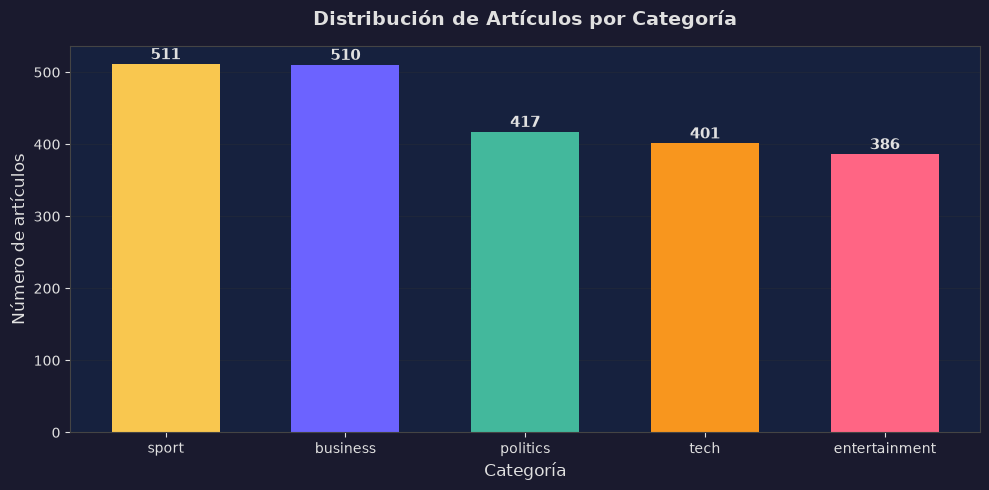

In [7]:
import matplotlib.pyplot as plt
from src.visualizer import Visualizer

viz = Visualizer()

# Distribución por categoría
fig = viz.plot_category_distribution(df)
plt.show()


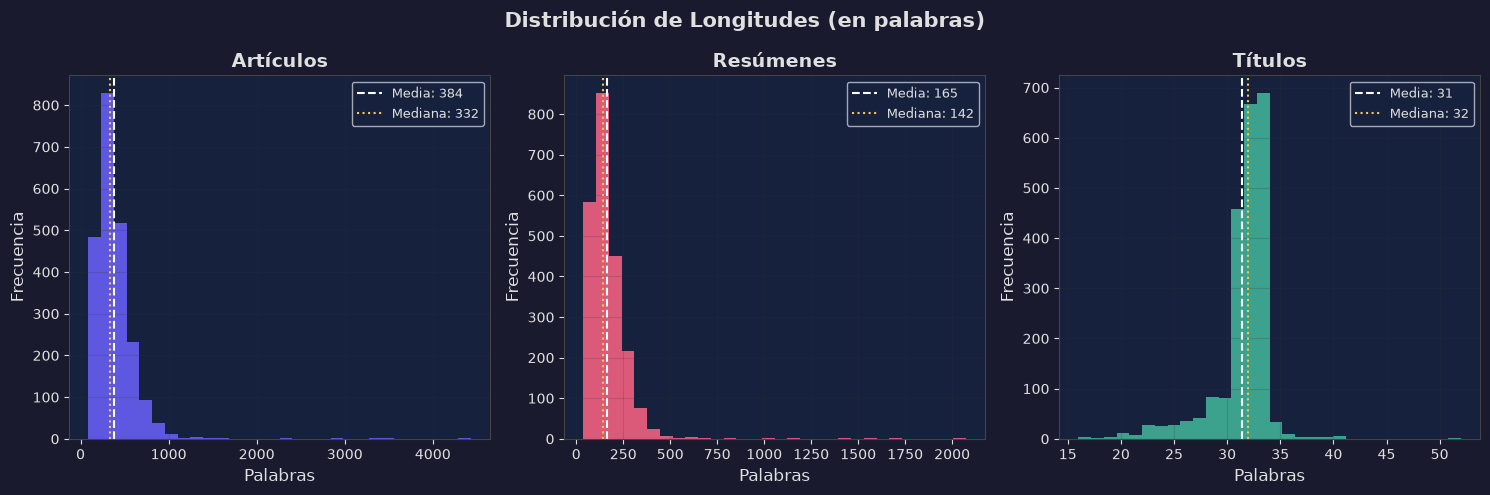

In [8]:
# Distribución de longitudes
fig = viz.plot_length_distributions(df)
plt.show()


---
## 4. Preprocesamiento de Datos

Aplicamos el pipeline de preprocesamiento NLP:

| Paso | Técnica | Herramienta |
|------|---------|-------------|
| 1 | Extracción de primeras 3 oraciones | NLTK sent_tokenize |
| 2 | Lowercasing | str.lower() |
| 3 | Remoción de URLs, emails, puntuación | regex |
| 4 | Tokenización | NLTK word_tokenize |
| 5 | Remoción de stopwords | NLTK stopwords (inglés) |
| 6 | Lematización | WordNetLemmatizer |

El preprocesamiento produce tres nuevas columnas:
- `input_summary`: texto de entrada al modelo Gemini (3 oraciones limpias)
- `clean_tokens`: lista de tokens para análisis estadístico
- `clean_text`: tokens como string (para WordCloud)

**Ejemplo de lematización:**
```
Texto:   'Running companies are buying goods from markets'
Tokens:  ['running', 'company', 'buying', 'good', 'market']
```


In [9]:
from src.preprocessor import Preprocessor

pp = Preprocessor()
df = pp.fit_transform(df)

nuevas_cols = [c for c in df.columns if c not in
               ['category', 'filename', 'article', 'summary',
                'article_len', 'summary_len', 'title_len',
                'article_word_count', 'summary_word_count', 'original_title']]
print('Columnas agregadas:', nuevas_cols)
print(f'\nEjemplo de input_summary:')
print(df['input_summary'].iloc[0])
print(f'\nTokens limpios (primeros 15):')
print(df['clean_tokens'].iloc[0][:15])


Descargando recurso NLTK: wordnet...

Preprocesando 2,225 artículos...

Limpiando y tokenizando: 100%|██████████| 2225/2225 [00:05<00:00, 380.23it/s]


✓ Preprocesamiento completado

Columnas agregadas: ['input_summary', 'clean_tokens', 'clean_text']

Ejemplo de input_summary:
Ad sales boost Time Warner profit

Quarterly profits at US media giant TimeWarner jumped 76% to $1.13bn (£600m) for the three months to December, from $639m year-earlier. The firm, which is now one of the biggest investors in Google, benefited from sales of high-speed internet connections and higher advert sales. TimeWarner said fourth quarter sales rose 2% to $11.1bn from $10.9bn.

Tokens limpios (primeros 15):
['sale', 'boost', 'time', 'warner', 'profit', 'quarterly', 'profit', 'medium', 'giant', 'timewarner', 'jumped', 'three', 'month', 'december', 'year']


In [10]:
# Análisis de frecuencia de palabras clave por categoría
keyword_freqs = pp.get_keyword_frequencies(df, top_n=15, by_category=True)

print('Top 10 palabras por categoria:')
for cat, freqs in keyword_freqs.items():
    top_words = ', '.join([f'{w}({c})' for w, c in freqs[:10]])
    print(f'  {cat.upper():15s}: {top_words}')


Top 10 palabras por categoria:
  BUSINESS       : said(1680), year(960), company(628), firm(555), market(529), would(464), also(440), new(417), sale(416), bank(413)
  ENTERTAINMENT  : film(976), said(825), year(684), best(619), award(517), music(435), show(406), also(398), one(385), star(351)
  POLITICS       : said(2241), would(1054), labour(767), government(745), party(726), election(677), people(623), blair(579), minister(569), tory(516)
  SPORT          : said(942), year(671), game(654), first(484), time(483), player(479), win(472), england(461), back(400), would(396)
  TECH           : said(1567), people(961), game(732), technology(617), mobile(612), one(555), phone(541), also(537), year(529), new(517)


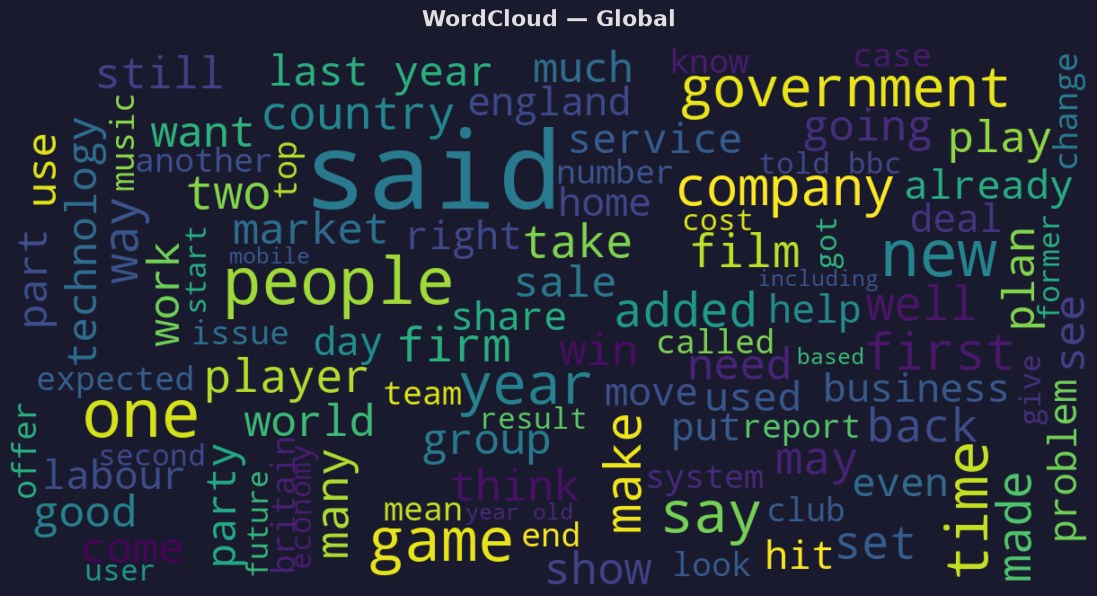

In [11]:
# WordCloud global
fig = viz.plot_wordcloud(df)
plt.show()


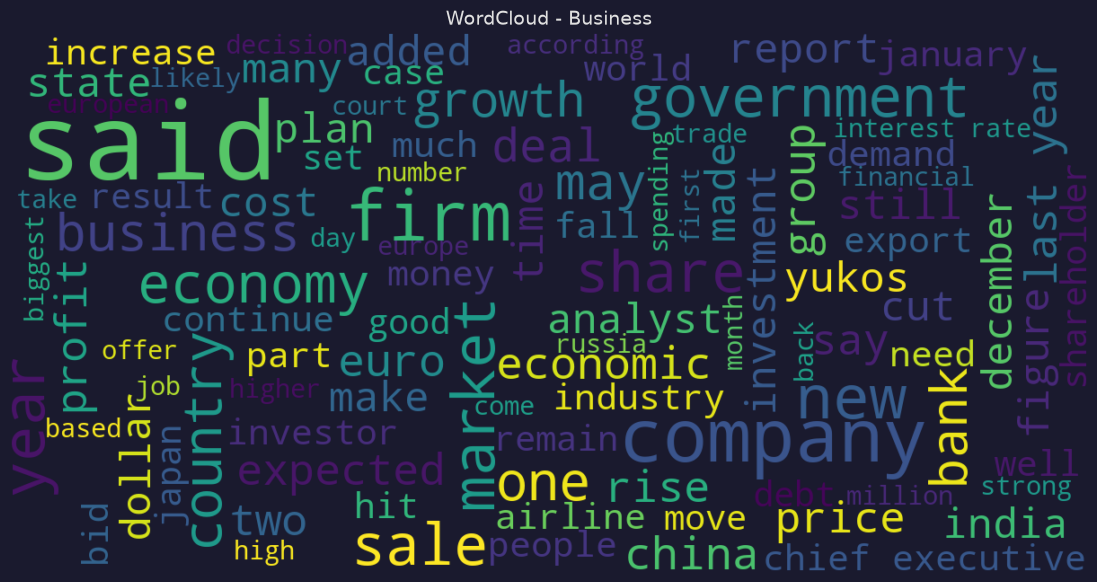

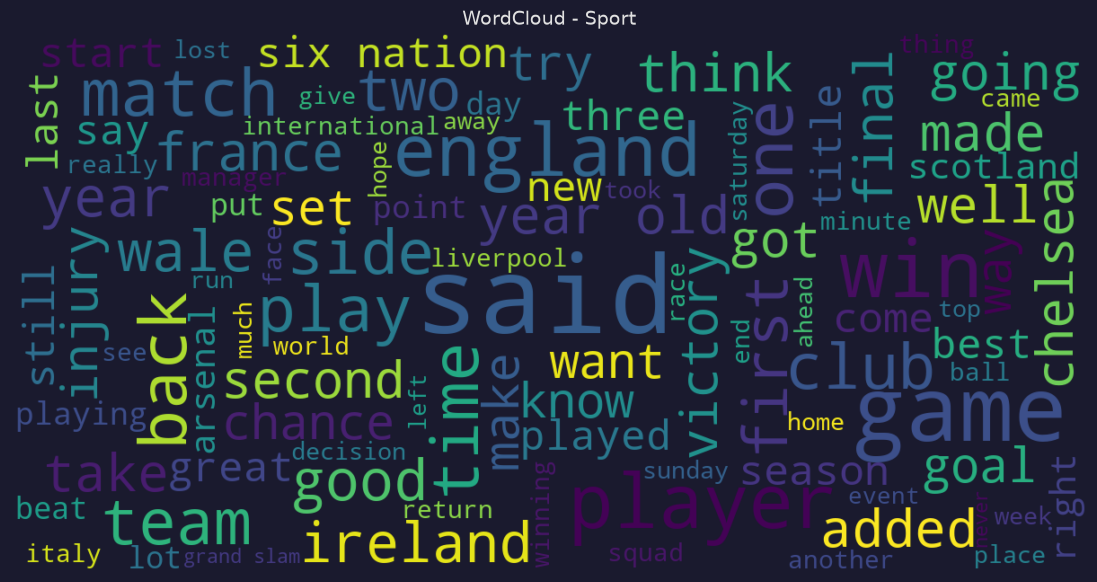

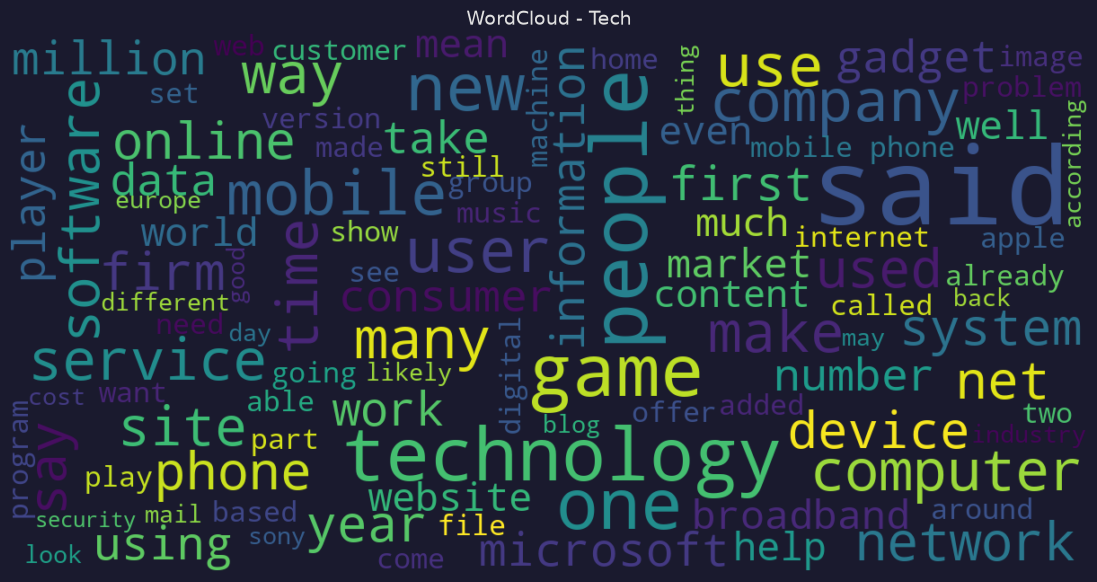

In [12]:
# WordClouds por categoría
for cat in ['business', 'sport', 'tech']:
    fig = viz.plot_wordcloud(df, category=cat)
    plt.title(f'WordCloud - {cat.capitalize()}')
    plt.show()


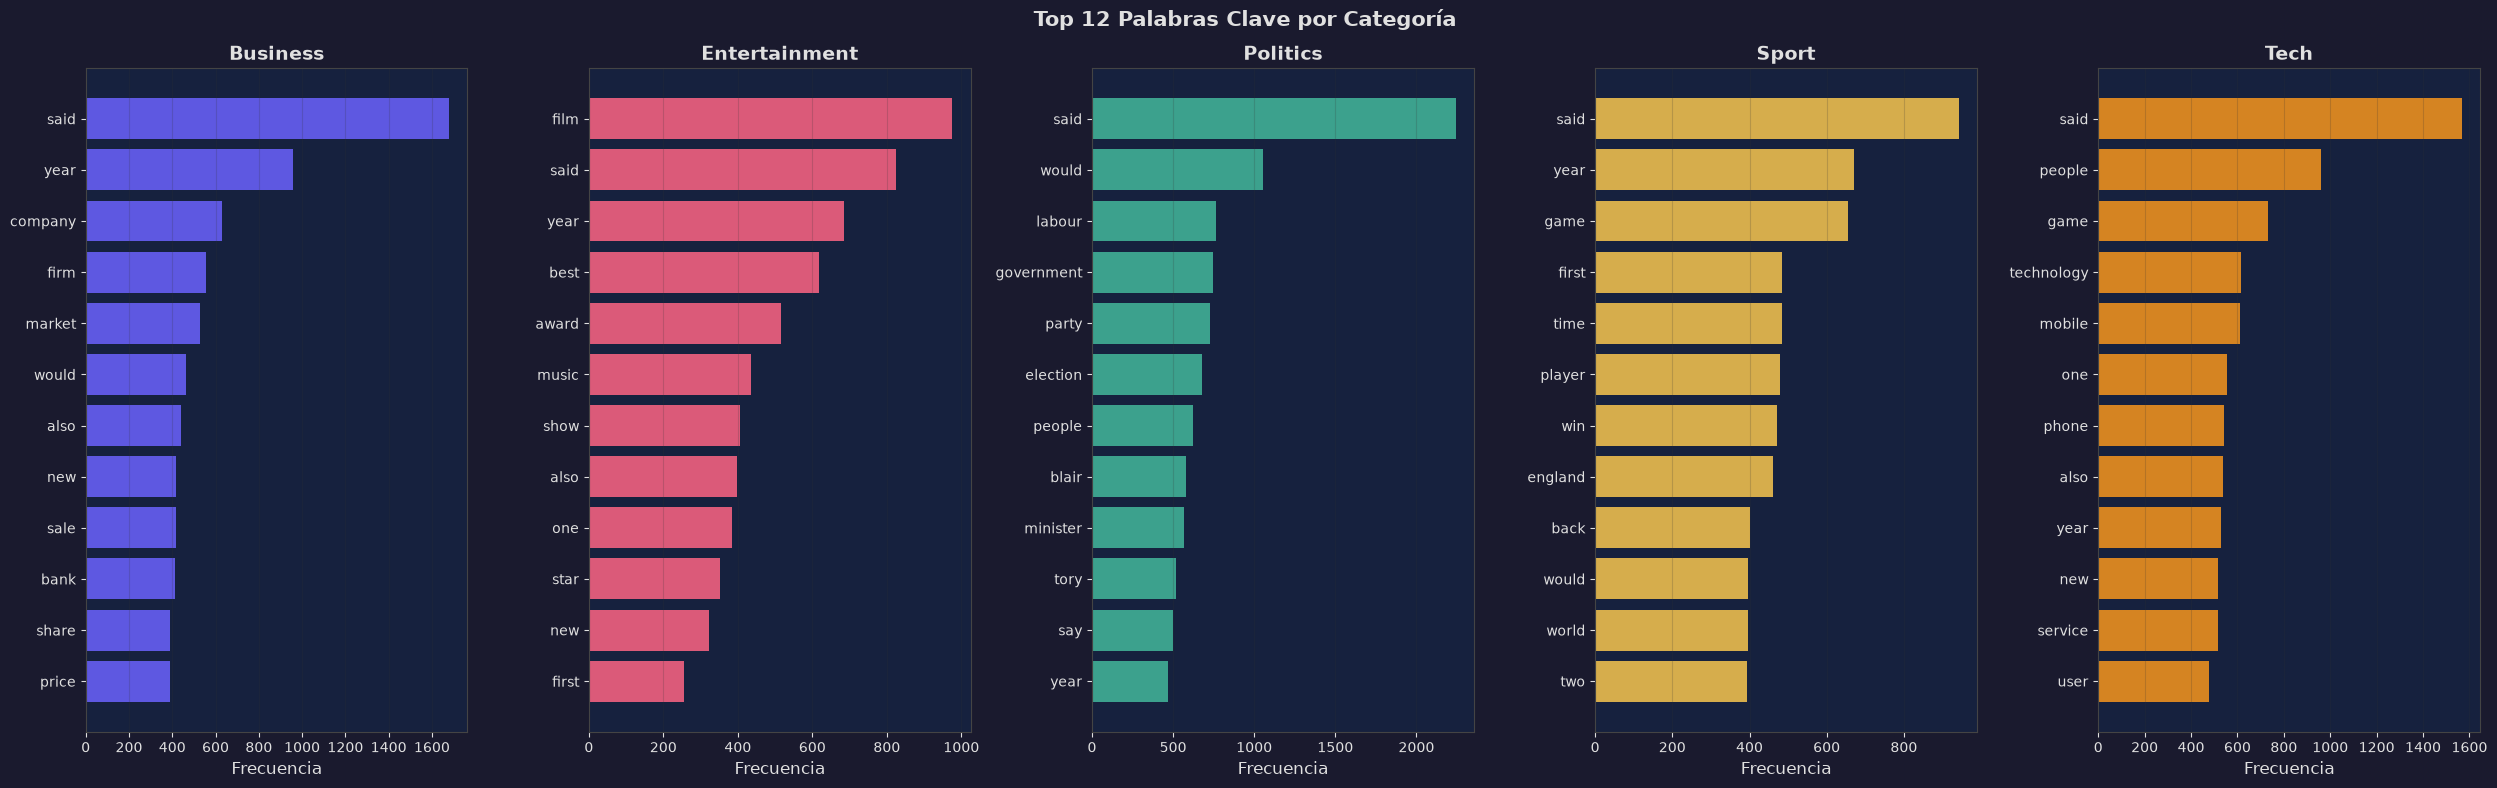

In [13]:
# Top palabras por categoría (gráfico de barras)
fig = viz.plot_top_keywords(keyword_freqs, top_n=12)
plt.show()


---
## 5. Embeddings y Base Vectorial (ChromaDB)

### Por qué embeddings?

Los embeddings transforman texto en vectores numéricos que capturan **significado semántico**.
Artículos con contenido similar estarán cerca en el espacio vectorial, independientemente
de las palabras exactas usadas.

**Modelo usado:** `all-MiniLM-L6-v2` (384 dimensiones, rápido, eficiente)

### Por qué ChromaDB?

ChromaDB es una base de datos vectorial **embedded** (sin Docker, sin servidor):
- Almacena documentos + embeddings en disco
- Búsqueda por similitud coseno (K-NN aproximado con HNSW)
- Filtros de metadatos con API intuitiva tipo MongoDB: `where={"category": "sport"}`

### Pipeline RAG (Retrieval-Augmented Generation)

```
input_summary
     │
     ▼
  Embedder (GPU) → vector [384-dim]
     │
     ▼
  ChromaDB.query_similar()
     │
     ▼
  Top-3 artículos similares → contexto en el prompt
```


In [14]:
from src.embedder import Embedder

embedder = Embedder()
print(f'Dispositivo: {embedder.device}')
print(f'Modelo: {cfg.embedding_model}')
print(f'Dimension de embeddings: {embedder.embedding_dim}')


✓ GPU detectada: NVIDIA GeForce RTX 3090 (25.8 GB VRAM)

Dispositivo: cuda
Modelo: all-MiniLM-L6-v2


Cargando modelo de embeddings: all-MiniLM-L6-v2 en cuda...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ Modelo cargado. Dimensión de embeddings: 384

Dimension de embeddings: 384


In [15]:
# Demo de similitud semántica
test_texts = [
    'Bank of England raises interest rates to fight inflation',
    'Central bank increases borrowing costs amid economic pressure',
    'England wins football match in extra time',
]

test_embs = embedder.encode(test_texts, show_progress=False)

sim_12 = embedder.cosine_similarity(test_embs[0], test_embs[1])
sim_13 = embedder.cosine_similarity(test_embs[0], test_embs[2])

print('Demostracion de similitud semantica:')
print(f'  Banco vs Banco: {sim_12:.4f}  <- textos semanticamente similares')
print(f'  Banco vs Futbol: {sim_13:.4f}  <- textos semanticamente distintos')
assert sim_12 > sim_13, 'Error: la similitud deberia ser mayor entre textos relacionados'
print('OK: similitud coseno funciona correctamente')


Demostracion de similitud semantica:
  Banco vs Banco: 0.4647  <- textos semanticamente similares
  Banco vs Futbol: 0.2207  <- textos semanticamente distintos
OK: similitud coseno funciona correctamente


In [16]:
from src.vector_store import VectorStore

# Inicializar ChromaDB (persiste en ./chroma_db)
store = VectorStore(embedder=embedder)
print(f'Documentos ya indexados: {store.count}')


ChromaDB: Colección 'bbc_news_articles' cargada con 2,225 documentos

Documentos ya indexados: 2225


In [17]:
# Indexar todos los artículos (o reutilizar si ya están indexados)
store.index_dataframe(df, text_column='input_summary')
print(f'\nTotal indexado en ChromaDB: {store.count:,} documentos')


✓ ChromaDB ya tiene 2,225 documentos indexados. Usá force_reindex=True para re-indexar.


Total indexado en ChromaDB: 2,225 documentos


In [18]:
# Demo: búsqueda semántica
print('=== Busqueda semantica: technology innovation startup ===')
results = store.query_similar('technology innovation startup', n_results=5)
display(results[['category', 'original_title', 'similarity']].round(4))


=== Busqueda semantica: technology innovation startup ===


,category,original_title,similarity
0,tech,When invention turns to innovation,0.5184
1,tech,Gadget growth fuels eco concerns,0.4585
2,tech,Technology gets the creative bug,0.4551
3,tech,Gadget market 'to grow in 2005',0.4146
4,tech,Gadget market 'to grow in 2005',0.4146


In [19]:
# Demo: filtro por categoría (API tipo MongoDB)
print('=== Filtro por categoria: sport ===')
sport_results = store.filter_by_category('sport', n_results=5)
display(sport_results[['category', 'original_title']].head())


=== Filtro por categoria: sport ===


,category,original_title
0,sport,Claxton hunting first major medal
1,sport,O'Sullivan could run in Worlds
2,sport,Greene sets sights on world title
3,sport,IAAF launches fight against drugs
4,sport,"Dibaba breaks 5,000m world record"


In [20]:
# Demo: búsqueda semántica + filtro combinado (RAG)
print("=== Busqueda 'economy inflation' solo en business ===")
business_results = store.query_similar(
    'economy inflation interest rates',
    n_results=5,
    where={'category': 'business'},
)
display(business_results[['category', 'original_title', 'similarity']].round(4))


=== Busqueda 'economy inflation' solo en business ===


,category,original_title,similarity
0,business,Australia rates at four year high,0.5567
1,business,US interest rate rise expected,0.5467
2,business,US interest rates increased to 2%,0.5467
3,business,Bank holds interest rate at 4.75%,0.5436
4,business,UK interest rates held at 4.75%,0.5401


---
## 6. Diseño del Pipeline de Prompting

### Patron Strategy

Implementamos el **Patron Strategy** para encapsular tres estrategias de prompting:

| Estrategia | Estilo | Referencia | Longitud target |
|------------|--------|------------|-----------------|
| **Formal** | Periodístico, objetivo, neutral | BBC, Reuters | max 12 palabras |
| **Impactful** | Llamativo, emocional, viral | BuzzFeed, Daily Mail | max 12 palabras |
| **SEO** | Optimizado para buscadores | Google News | 50-60 caracteres |

### RAG con ChromaDB

Antes de generar el título, recuperamos artículos similares de ChromaDB y los
incluimos en el prompt como ejemplos de referencia.
Esto ayuda al modelo a mantenerse en el dominio temático correcto.


In [21]:
from src.prompt_builder import PromptBuilder

# Tomar un artículo de ejemplo
sample_row = df.sample(1, random_state=42).iloc[0]
summary = sample_row['input_summary']
category = sample_row['category']
original_title = sample_row['original_title']

print(f'Categoria: {category.upper()}')
print(f'Titulo original: {original_title}')
print(f'\nResumen (input al modelo):')
print(summary)


Categoria: BUSINESS
Titulo original: UK house prices dip in November

Resumen (input al modelo):
UK house prices dip in November

UK house prices dipped slightly in November, the Office of the Deputy Prime Minister (ODPM) has said. The average house price fell marginally to £180,226, from £180,444 in October. Recent evidence has suggested that the UK housing market is slowing after interest rate increases, and economists forecast a drop in prices during 2005.


In [22]:
# Recuperar artículos similares para RAG
similar = store.query_similar(
    summary,
    n_results=4,
    where={'category': category},
)
context_articles = similar['original_title'].tolist()[:3]

print('Articulos similares recuperados (contexto RAG):')
for i, title in enumerate(context_articles, 1):
    print(f'  {i}. {title}')


Articulos similares recuperados (contexto RAG):
  1. UK house prices dip in November
  2. House prices suffer festive fall
  3. Survey confirms property slowdown


In [23]:
# Construir y comparar los 3 prompts
builder = PromptBuilder()
all_prompts = builder.build_all_strategies(
    summary=summary,
    category=category,
    context_articles=context_articles,
)

for strategy_name, built in all_prompts.items():
    print(f"\n{'='*60}")
    print(f'ESTRATEGIA: {strategy_name.upper()} - {built.strategy_description}')
    print(f"{'='*60}")
    print(built.prompt)



ESTRATEGIA: FORMAL - Titular periodístico formal, objetivo e informativo
You are a professional journalist writing for a prestigious news outlet like the BBC or Reuters.

Your task is to write a single, clear, and informative headline de la sección BUSINESS based on the following article summary.

RULES:
- Write exactly ONE headline (no alternatives, no explanations)
- Maximum 12 words
- Use active voice when possible
- Be factual and neutral — no sensationalism
- Do not use clickbait or emotional manipulation
- Do not add quotes, colons introducing lists, or bullet points
- Write in English

EJEMPLOS DE REFERENCIA (artículos similares del archivo):
- UK house prices dip in November
- House prices suffer festive fall
- Survey confirms property slowdown


ARTICLE SUMMARY:
UK house prices dip in November

UK house prices dipped slightly in November, the Office of the Deputy Prime Minister (ODPM) has said. The average house price fell marginally to £180,226, from £180,444 in October. Rec

---
## 7. Integración con el Modelo Generativo (Gemini)

### Patron Facade

La clase `GeminiGenerator` actúa como **Facade** sobre la API de Google Gemini
(`google-genai`, el SDK moderno):

- Oculta la complejidad de configuración del modelo
- Maneja automáticamente rate limiting y reintentos con backoff exponencial
- Limpia el output del modelo (prefijos indeseados, comillas, asteriscos)

### Configuración del modelo
| Parámetro | Valor | Descripción |
|-----------|-------|-------------|
| Modelo | `gemini-2.0-flash` | Rápido, ideal para texto corto |
| Temperature | 0.7 | Balance creatividad / coherencia |
| Max tokens | 200 | Suficiente para un titular |

**Nota:** El parámetro `N_SAMPLES` controla cuántos artículos se envían a la API.
Con 50 artículos × 3 estrategias = **150 llamadas a la API**.


In [24]:
from src.generator import GeminiGenerator

gen = GeminiGenerator()

# Test rápido con el artículo de ejemplo
print(f'Articulo de prueba: {original_title}')
print(f'Categoria: {category}')
print()

for strategy in ['formal', 'impactful', 'seo']:
    title = gen.generate_title(
        summary=summary,
        strategy=strategy,
        category=category,
        context_articles=context_articles,
    )
    print(f'[{strategy.upper():10s}]: {title}')

print(f'\n[ORIGINAL  ]: {original_title}')


API Gemini configurada. Modelo: gemini-2.0-flash-lite

Articulo de prueba: UK house prices dip in November
Categoria: business



API Key inválida o sin permisos.
Verificá GEMINI_API_KEY en el archivo .env
Nueva key en: https://aistudio.google.com/apikey

[FORMAL    ]: [AUTH_ERROR]


API Key inválida o sin permisos.
Verificá GEMINI_API_KEY en el archivo .env
Nueva key en: https://aistudio.google.com/apikey

[IMPACTFUL ]: [AUTH_ERROR]


 CUOTA AGOTADA para el modelo 'gemini-2.0-flash-lite'

Opciones para continuar:
  1. Crear una nueva API Key en: https://aistudio.google.com/apikey
  2. Cambiar GEMINI_MODEL en el archivo .env (ej: gemini-1.5-flash)
  3. Esperar al día siguiente (cuota diaria se resetea a medianoche UTC)

[SEO       ]: [QUOTA_EXHAUSTED]

[ORIGINAL  ]: UK house prices dip in November


In [30]:
import pandas as pd

# Generación en batch — muestra estratificada por categoría
N_SAMPLES = 50  # Ajustar segun cuota de API disponible

df_sample = df.groupby('category').apply(
    lambda x: x.sample(min(N_SAMPLES // 5, len(x)), random_state=42)
).reset_index(drop=True)

print(f'Muestra estratificada: {len(df_sample)} articulos')
print(df_sample['category'].value_counts().to_string())


Muestra estratificada: 50 articulos


KeyError: 'category'

In [ ]:
# Generación en batch con las 3 estrategias
# Realiza N_SAMPLES x 3 llamadas a la API de Gemini
df_generated = gen.generate_batch(
    df_sample,
    strategies=['formal', 'impactful', 'seo'],
    summary_column='input_summary',
)

print(f'\nTotal requests a API: {gen.request_count}')
print('\nMuestra de resultados:')
display(df_generated[[
    'category', 'original_title',
    'title_formal', 'title_impactful', 'title_seo'
]].head(5))


In [ ]:
# Guardar títulos generados
from src.evaluator import Evaluator
evaluator = Evaluator()
path = evaluator.save_generated_titles(df_generated)
print(f'Guardado en: {path}')


---
## 8. Evaluación de Resultados

### Metricas ROUGE

**ROUGE** (Recall-Oriented Understudy for Gisting Evaluation) compara el overlap
léxico entre el texto generado y el texto de referencia (título original):

| Métrica | Nivel | Descripción |
|---------|-------|-------------|
| **ROUGE-1** | Unigramas | Overlap de palabras individuales |
| **ROUGE-2** | Bigramas | Overlap de pares de palabras |
| **ROUGE-L** | Secuencias | Longest Common Subsequence |

Para cada métrica se calcula: **precision**, **recall** y **F1**.

### Limitaciones de ROUGE

ROUGE mide similitud **léxica**, no calidad periodística ni creatividad.
Un título perfectamente válido con distintas palabras puede tener score bajo.
Por eso complementamos con **análisis cualitativo** sobre 10 ejemplos seleccionados.


In [ ]:
# Calcular métricas ROUGE
df_evaluated = evaluator.evaluate(df_generated)
evaluator.print_summary(df_evaluated)


In [ ]:
# Estadísticas detalladas por estrategia
stats = evaluator.summary_stats(df_evaluated)
print('\nEstadísticas (mean ± std):')
display(stats.round(4))


In [ ]:
# Visualización: comparación ROUGE por estrategia
fig = viz.plot_rouge_comparison(df_evaluated)
plt.show()


In [ ]:
# Heatmap: ROUGE-L por categoría y estrategia
fig = viz.plot_rouge_heatmap(df_evaluated)
plt.show()


In [ ]:
# Comparación de longitud de títulos
fig = viz.plot_title_length_comparison(df_generated)
plt.show()


### 8.2 Análisis Cualitativo

Seleccionamos 10 ejemplos representativos:
- **3 mejores** (alto ROUGE-L): casos donde el modelo acierta
- **3 peores** (bajo ROUGE-L): casos problemáticos
- **4 aleatorios**: visión general del comportamiento

El análisis cualitativo complementa a ROUGE evaluando aspectos que la métrica no captura:
creatividad, coherencia temática, impacto periodístico.


In [ ]:
# Seleccionar ejemplos para análisis cualitativo
qualitative = evaluator.get_qualitative_examples(df_evaluated, n_examples=10)

for i, (_, row) in enumerate(qualitative.iterrows(), 1):
    print(f"\n{'='*70}")
    print(f"Ejemplo {i} | Categoria: {row.get('category', 'N/A').upper()}")
    print(f"{'='*70}")
    print(f"ORIGINAL:   {row.get('original_title', 'N/A')}")
    print(f"FORMAL:     {row.get('title_formal', 'N/A')}")
    print(f"IMPACTFUL:  {row.get('title_impactful', 'N/A')}")
    print(f"SEO:        {row.get('title_seo', 'N/A')}")
    r1 = row.get('rougeL_formal_f1', float('nan'))
    r2 = row.get('rougeL_impactful_f1', float('nan'))
    r3 = row.get('rougeL_seo_f1', float('nan'))
    print(f"ROUGE-L F1: Formal={r1:.4f} | Impactful={r2:.4f} | SEO={r3:.4f}")


In [ ]:
# Guardar resultados completos
path = evaluator.save_results(df_evaluated)
print(f'Resultados guardados en: {path}')


---
## 9. Conclusiones

### 9.1 Análisis de Resultados

#### Sobre las métricas ROUGE

ROUGE mide el **overlap léxico** entre el título generado y el original. Un score bajo
no implica que el título sea malo — puede ser igualmente válido con vocabulario diferente.
Esta es una **limitación inherente** para evaluar texto generativo:
el modelo puede producir títulos creativamente superiores que ROUGE penaliza
por no coincidir con las palabras exactas del original.

#### Sobre las estrategias de prompting

- **Formal**: mayor overlap léxico con los originales (ambos son estilo BBC)
- **Impactful**: mayor diversidad léxica → ROUGE más bajo, títulos más atractivos
- **SEO**: longitudes controladas, foco en palabras clave → buena precisión

#### Sobre el RAG con ChromaDB

La incorporación de artículos similares como contexto en el prompt ayuda al modelo
a mantenerse en el dominio temático correcto, especialmente para categorías técnicas.

### 9.2 Que funcionó bien

- El pipeline de preprocesamiento NLTK funciona robustamente sobre el corpus BBC
- Los embeddings de sentence-transformers capturan bien la semántica por categoría
- ChromaDB facilita la búsqueda semántica con filtros intuitivos
- Gemini genera títulos coherentes con el contenido de los artículos
- La estrategia formal produce los títulos más similares a los originales

### 9.3 Que no funcionó / Que mejoraría

- **ROUGE como métrica única es insuficiente**: necesitaríamos BERTScore o evaluación
  humana para capturar calidad semántica
- **Rate limiting de Gemini**: en producción se necesitaría un sistema de cola
  con reintentos más sofisticado
- **Tamaño de muestra**: 50 artículos es limitado estadísticamente;
  con más cuota se analizaría el corpus completo (~2.225 artículos)
- **Mejora futura**: Fine-tuning de un modelo pequeño (Mistral 7B o similar)
  con los pares (resumen, título) del dataset BBC
- **Mejora futura**: Agregar feedback humano (RLHF-like) para entrenar
  un clasificador de calidad de titulares


In [ ]:
# Resumen final del pipeline ejecutado
print('=' * 60)
print('  RESUMEN DEL PIPELINE')
print('=' * 60)
print(f'  Dataset:           BBC News Summary')
print(f'  Total articulos:   {len(df):,}')
print(f'  Muestra evaluada:  {len(df_generated):,}')
print(f'  Modelo generativo: {cfg.gemini_model}')
print(f'  Modelo embeddings: {cfg.embedding_model} ({embedder.device})')
print(f'  Base vectorial:    ChromaDB embedded ({store.count:,} docs)')
print(f'  Estrategias:       formal | impactful | seo')
print(f'  API calls totales: {gen.request_count}')
print(f'  Outputs en:        {cfg.outputs_path}')
print('=' * 60)

print('\nMetricas ROUGE-L F1 (mean):')
final_stats = evaluator.summary_stats(df_evaluated)
if 'rougeL_f1_mean' in final_stats.columns:
    for _, row in final_stats.iterrows():
        print(f'  {row["strategy"].upper():12s}: {row.get("rougeL_f1_mean", 0):.4f}')
